In [7]:
# https://www.ercot.com/files/docs/2009/05/20/modelingguidelines_v06.pdf

In [1]:
import pandas as pd
from modo_energy_client.modo_energy_api_client import ModoEnergyAPIClient
from datetime import date
import numpy as np
from scipy.stats.mstats import winsorize
import statsmodels.api as sm

c:\Users\andre\Source\modo_energy\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
client = ModoEnergyAPIClient(cache_requests=True)

In [4]:
prices = client.get_ercot_prices(date(2024, 7, 1), date(2026, 5, 31))

Fetching pages : 26page [00:00, 27.48page/s]


In [5]:
prices

,hourEnding,repeatedHourFlag,settlementPointName,settlementPointPrice
deliveryDate,,,,
2026-05-31 23:00:00,24,N,LZ_WEST,29.46
2026-05-31 23:00:00,24,N,LZ_SOUTH,27.27
2026-05-31 23:00:00,24,N,LZ_RAYBN,26.84
2026-05-31 23:00:00,24,N,LZ_NORTH,26.85
2026-05-31 23:00:00,24,N,LZ_LCRA,27.33
...,...,...,...,...
2024-07-01 00:00:00,1,N,HB_PAN,14.99
2024-07-01 00:00:00,1,N,HB_NORTH,20.42
2024-07-01 00:00:00,1,N,HB_HUBAVG,20.44


In [6]:
hb_bus_avg_price = prices[prices["settlementPointName"] == "HB_HOUSTON"][
    "settlementPointPrice"
].astype(int)

In [7]:
hb_bus_avg_price_winsorized = pd.DataFrame(
    {hb_bus_avg_price.name: winsorize(hb_bus_avg_price, limits=[None, 0.01])},
    index=hb_bus_avg_price.index,
)

In [9]:
arbitrage_opportunity = (
    hb_bus_avg_price_winsorized.resample("D")
    .agg(lambda d: d[d.index.hour == 19].item() - d[d.index.hour == 12].item())
    .rename(columns={"settlementPointPrice": "arbitrage_opportunity"})
).astype(int)


<Axes: xlabel='deliveryDate'>

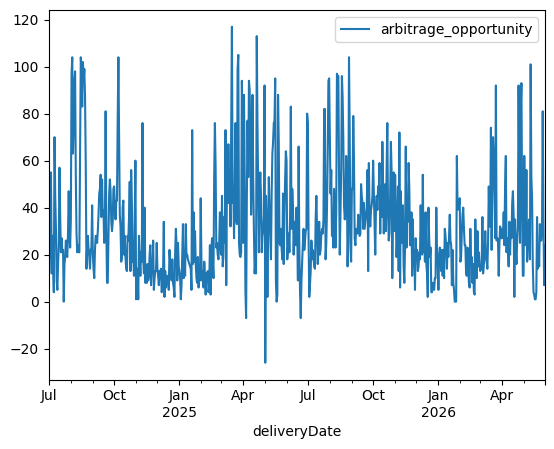

In [10]:
arbitrage_opportunity.plot()

In [11]:
day_of_week_dummies = pd.get_dummies(
    pd.Series(
        arbitrage_opportunity.index.day_name(), index=arbitrage_opportunity.index
    ),
    drop_first=True,
)

In [12]:
month_dummies = pd.get_dummies(
    pd.Series(
        arbitrage_opportunity.index.month_name(), index=arbitrage_opportunity.index
    ),
    drop_first=True,
)

In [18]:
X = pd.DataFrame(
    {
        "month": arbitrage_opportunity.index.month_name(),
        "day_of_week": arbitrage_opportunity.index.day_name(),
    },
    index=arbitrage_opportunity.index,
)

In [13]:
X = day_of_week_dummies.join(month_dummies).astype(float)

In [14]:
reg = sm.OLS(
    arbitrage_opportunity["arbitrage_opportunity"],
    sm.add_constant(X),
).fit()

In [15]:
reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     arbitrage_opportunity   R-squared:                       0.225
Model:                               OLS   Adj. R-squared:                  0.206
Method:                    Least Squares   F-statistic:                     11.65
Date:                   Mon, 15 Jun 2026   Prob (F-statistic):           2.07e-28
Time:                           10:34:11   Log-Likelihood:                -3111.9
No. Observations:                    700   AIC:                             6260.
Df Residuals:                        682   BIC:                             6342.
Df Model:                             17                                         
Covariance Type:               nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         39.0816      3.334     11.723      0.000      32.536      45.627
Monday         4.4989      2.959      1.521      0.129      -1.310      10.308
Saturday      -4.4208      2.956     -1.496      0.135     -10.224       1.383
Sunday         3.4096      2.957      1.153      0.249      -2.396       9.216
Thursday       4.5937      2.956      1.554      0.121      -1.210      10.398
Tuesday        3.5810      2.958      1.211      0.226      -2.227       9.389
Wednesday      4.9632      2.958      1.678      0.094      -0.844      10.770
August        12.4157      3.786      3.279      0.001       4.981      19.850
December     -25.1548      3.785     -6.645      0.000     -32.587     -17.722
February     -21.1174      3.883     -5.438      0.000     -28.742     -13.493
January      -21.2708      3.785     -5.619      0.000     -28.703     -13.838
July         -11.4717      3.785     -3.031      0.003     -18.902      -4.041
June         -10.3619      4.674     -2.217      0.027     -19.540      -1.184
March         -1.5006      3.786     -0.396      0.692      -8.935       5.934
May           -6.8262      3.786     -1.803      0.072     -14.261       0.608
November     -17.0578      3.817     -4.469      0.000     -24.552      -9.563
October       -1.3670      3.785     -0.361      0.718      -8.798       6.064
September     -4.7648      3.817     -1.248      0.212     -12.259       2.729
==============================================================================
Omnibus:                       87.930   Durbin-Watson:                   1.292
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              122.810
Skew:                           0.911   Prob(JB):                     2.15e-27
Kurtosis:                       3.943   Cond. No.                         13.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""